# Introduction

The purpose of this script is to determine the symmetry of the Fermi surface of YbPdBi, a material which has demonstrated interesting quantum effects (which I happen to have written my thesis discussing!). A [Fermi surface](https://en.wikipedia.org/wiki/Fermi_surface) is a quantum mechanical structure that determines many of the electronic transport properties of a material (that is to say, the way electricity runs through it). For example, this surface will be different for metals, semi-conductors, and insulators. This discussion is beyond the scope of this demonstration, but free to shoot me an email if you're curious about learning about this.

In order to do this, I took angle-resolved magnetoresistance oscillation (AMRO) data, wherein I measure the longitudinal resistivity of a rectangular prism sample as it rotates within a strong applied magnetic field. Resistivity is an intrinsic analogue to resistance, which you are likely more familiar with. This resistivity was measured in both positive and negative magnetic field values, and then symmetrized to minimize the influence of sample misalignment and any transverse resistivity that may be present.

Such data is of research interest because the symmetry of the AMRO (e.g. how many times the resistivity repeats per sample rotation) is determined by the Fermi surface. A significant change in the AMRO symmetry indicates a significant change in the Fermi surface structure. This is an unusual occurance and indicative of a significant change in the quantum physics of the material.

Investigations of such behaviour can help us discover new materials for use in technologies of the future.

In [12]:
%load_ext autoreload

%autoreload 2

import matplotlib.pyplot as plt
from amro.config import settings
from amro import Fourier
from amro import AMROFitter
from amro import AMROLoader




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load AMRO Data

Loading in partially pre-processed angle-resolved magnetoresistance oscillation (**AMRO**) data. The pre-processing consists of anti-symmetrizing the raw data taken from in the laboratory.

**AMRO** data is obtained by measuring the resistivity of a sample as it is rotated in a constant magnetic field. The changes in the resistivity during this rotation provide information relating to the **Fermi surface** of the material, which governs the behaviour of electrons during such measurements. The **Fermi surface** is a product of the quantum nature of the electrons, and its shape is primarily determined by the structure/arrangement of the material's constituent elements.

The Fermi surface is a surface of constant energy in the momentum space (**k-space**) of the electrons.

Loading : AMRO_combined_datab.csv
40 unique experiments were found and loaded.


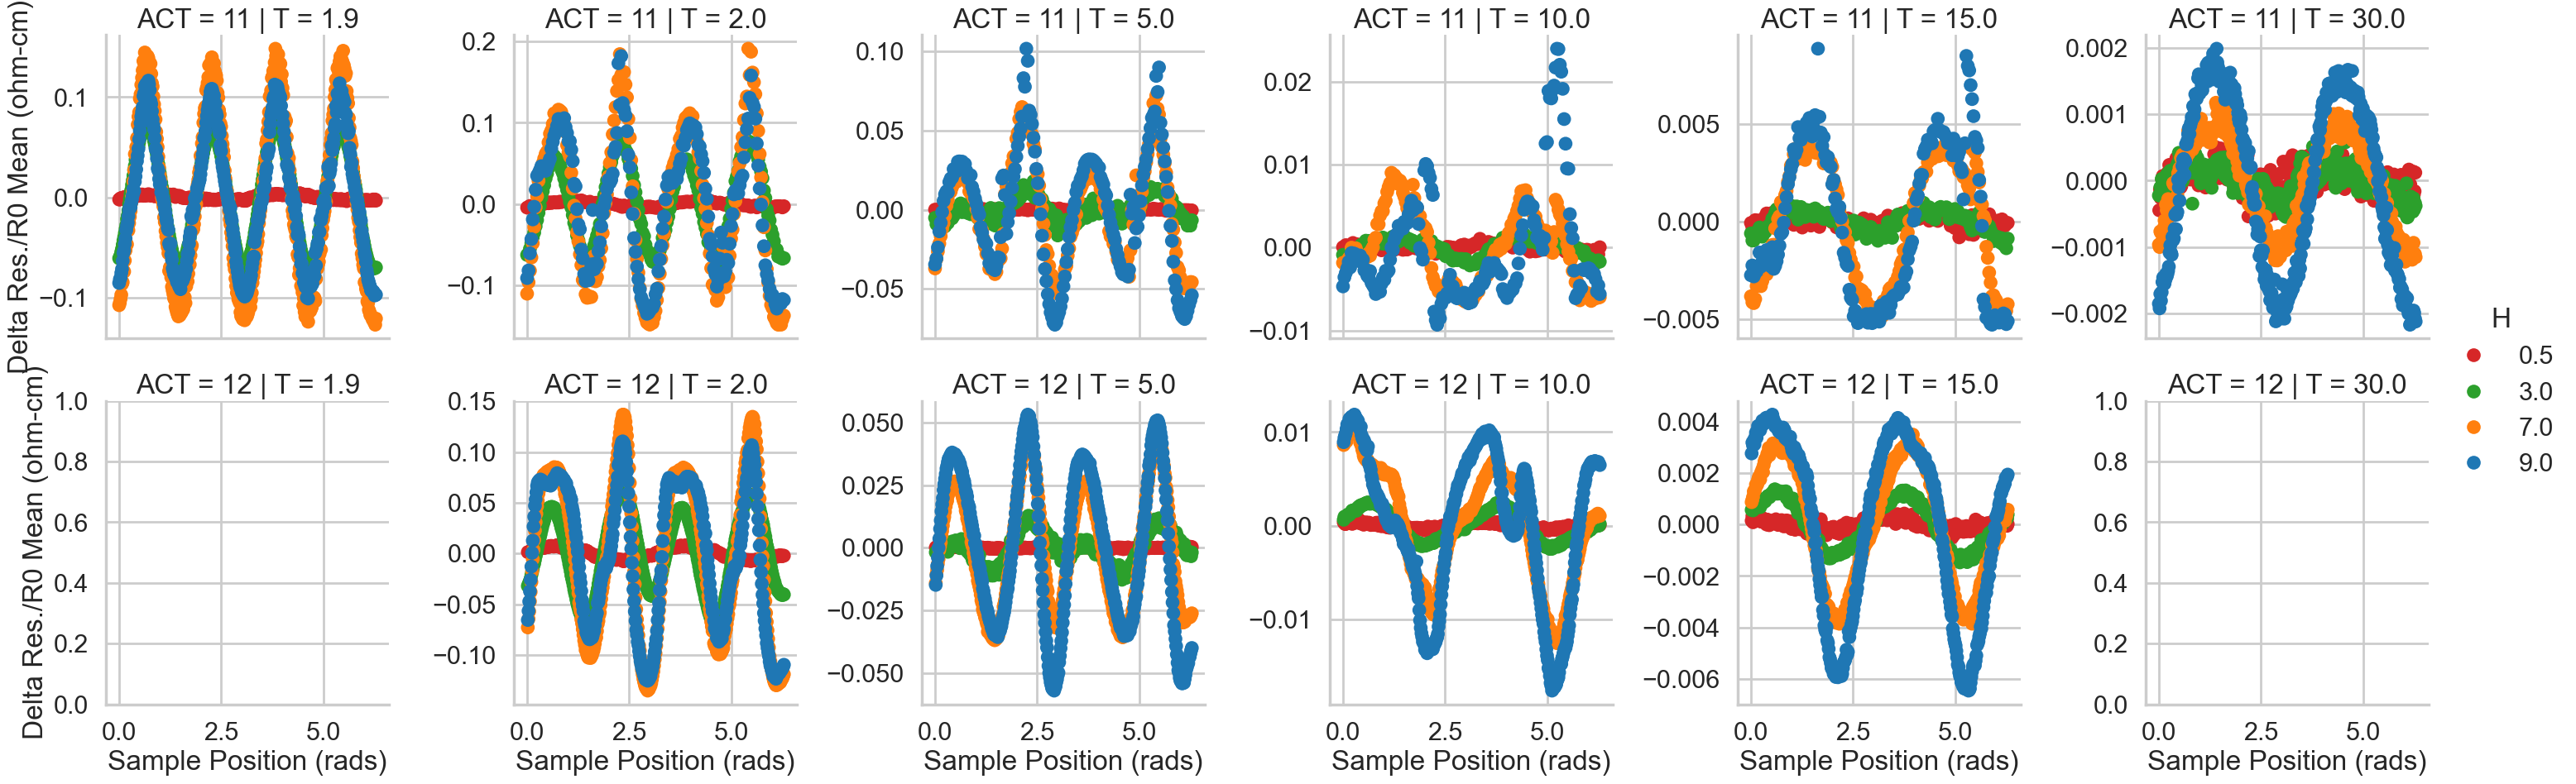

In [13]:
amro = AMROLoader('AMRO_combined_datab.csv')
amro_df = amro.get_amro()

amro.quick_plot_amro()

# Fourier Transform

In order to determine good initial guesses for the sinusoidal fitting, I Fourier transform this data.

The advantage to using a Fourier transform for this analysis is that the results of a Fourier transform do not depend on the choice of fitting function. This reduces the influence of personal biases, and also improves the comparability of results between AMRO-based research publications. One downside is the difficulty in determining our measurement uncertainties, an important part of science. This is why I later fit the data with sinusoids.

Each wave created by the resistivity as the sample is rotated can be deconstructed into a sum of sinusoidal waves. I am interested in the strengths of these oscillations, as one can garner information about the Fermi surface structure.

NB: I don't want to use these as final results. By using these as an initial best guess for a regression, I can take noise into account and better quantify the uncertainties.


In [4]:
fourier = Fourier(amro_df, 'AMRO_fourier_transform_results.csv')
# g = fourier.PlotNStrongest(n=5, H=[0.5, 3, 7, 9],T=[5, 10, 15])


Loading AMRO_fourier_transform_results.csv


In [5]:
import warnings
warnings.filterwarnings('error')

fourier.fourier_transform_experiments()


FT'ing: ACTRot11
FT'ing: ACTRot12
Results saved to: AMRO_fourier_transform_results.csv


In [6]:
FT_results_df = fourier.get_n_strongest_results(0)


# Sinusoidal Fits


## Fitting Function
We fit the AMRO data using a function of the form :

$\quad\quad\rho_{xx}(\theta) = \rho_0\left(1 + \sum_i a_i\sin(f_i\theta+\phi_i)\right)$

where $\theta$ is the angle of sample rotation, $\rho_0$ is the mean resistivity, $f_i$ is the value of the symmetry (i.e. $f_2=2$ for the 2-fold symmetry), $a_i$ is the amplitude of the $i$-th symmetry and $\phi_i$ is it's phase. We are primarily interested in the values of $a_i$, which correlate to the dominant rotational symmetry of the Fermi surface. Values of $\phi_i$ correspond to a rotation in k-space.

As initial guesses for $a_i$, we use the results of the previous Fourier transforms.

In [7]:
fitter = AMROFitter(amro_df, FT_results_df,
                    save_name='amro_fits',
                   # if_save_file_exists_overwrite=True,
                    min_amp_ratio= 0.075, #1,
                    max_freq=8, # 12,
                    force_four_and_two_sym=True,
                    verbose=False)


Loading previous fit results.


In [8]:
for ACT_label in ['ACTRot11', 'ACTRot12']:
    fitter.fit_act_experiment(label=ACT_label)
fit_params = fitter.get_fitted_parameters()


Already fitted ACTRot11, 10.0K, 0.5T. Skipping...
Already fitted ACTRot11, 10.0K, 3.0T. Skipping...
Already fitted ACTRot11, 10.0K, 7.0T. Skipping...
Already fitted ACTRot11, 10.0K, 9.0T. Skipping...
Already fitted ACTRot11, 15.0K, 0.5T. Skipping...
Already fitted ACTRot11, 15.0K, 3.0T. Skipping...
Already fitted ACTRot11, 15.0K, 7.0T. Skipping...
Already fitted ACTRot11, 15.0K, 9.0T. Skipping...
Already fitted ACTRot11, 1.9K, 0.5T. Skipping...
Already fitted ACTRot11, 1.9K, 3.0T. Skipping...
Already fitted ACTRot11, 1.9K, 7.0T. Skipping...
Already fitted ACTRot11, 1.9K, 9.0T. Skipping...
Already fitted ACTRot11, 2.0K, 0.5T. Skipping...
Already fitted ACTRot11, 2.0K, 3.0T. Skipping...
Already fitted ACTRot11, 2.0K, 7.0T. Skipping...
Already fitted ACTRot11, 2.0K, 9.0T. Skipping...
Already fitted ACTRot11, 30.0K, 0.5T. Skipping...
Already fitted ACTRot11, 30.0K, 3.0T. Skipping...
Already fitted ACTRot11, 30.0K, 7.0T. Skipping...
Already fitted ACTRot11, 30.0K, 9.0T. Skipping...
Already 

## Check the Fit Results

Saved ACTRot11_figure_amro_fits_ratio_0p075_maxf_8_.pdf


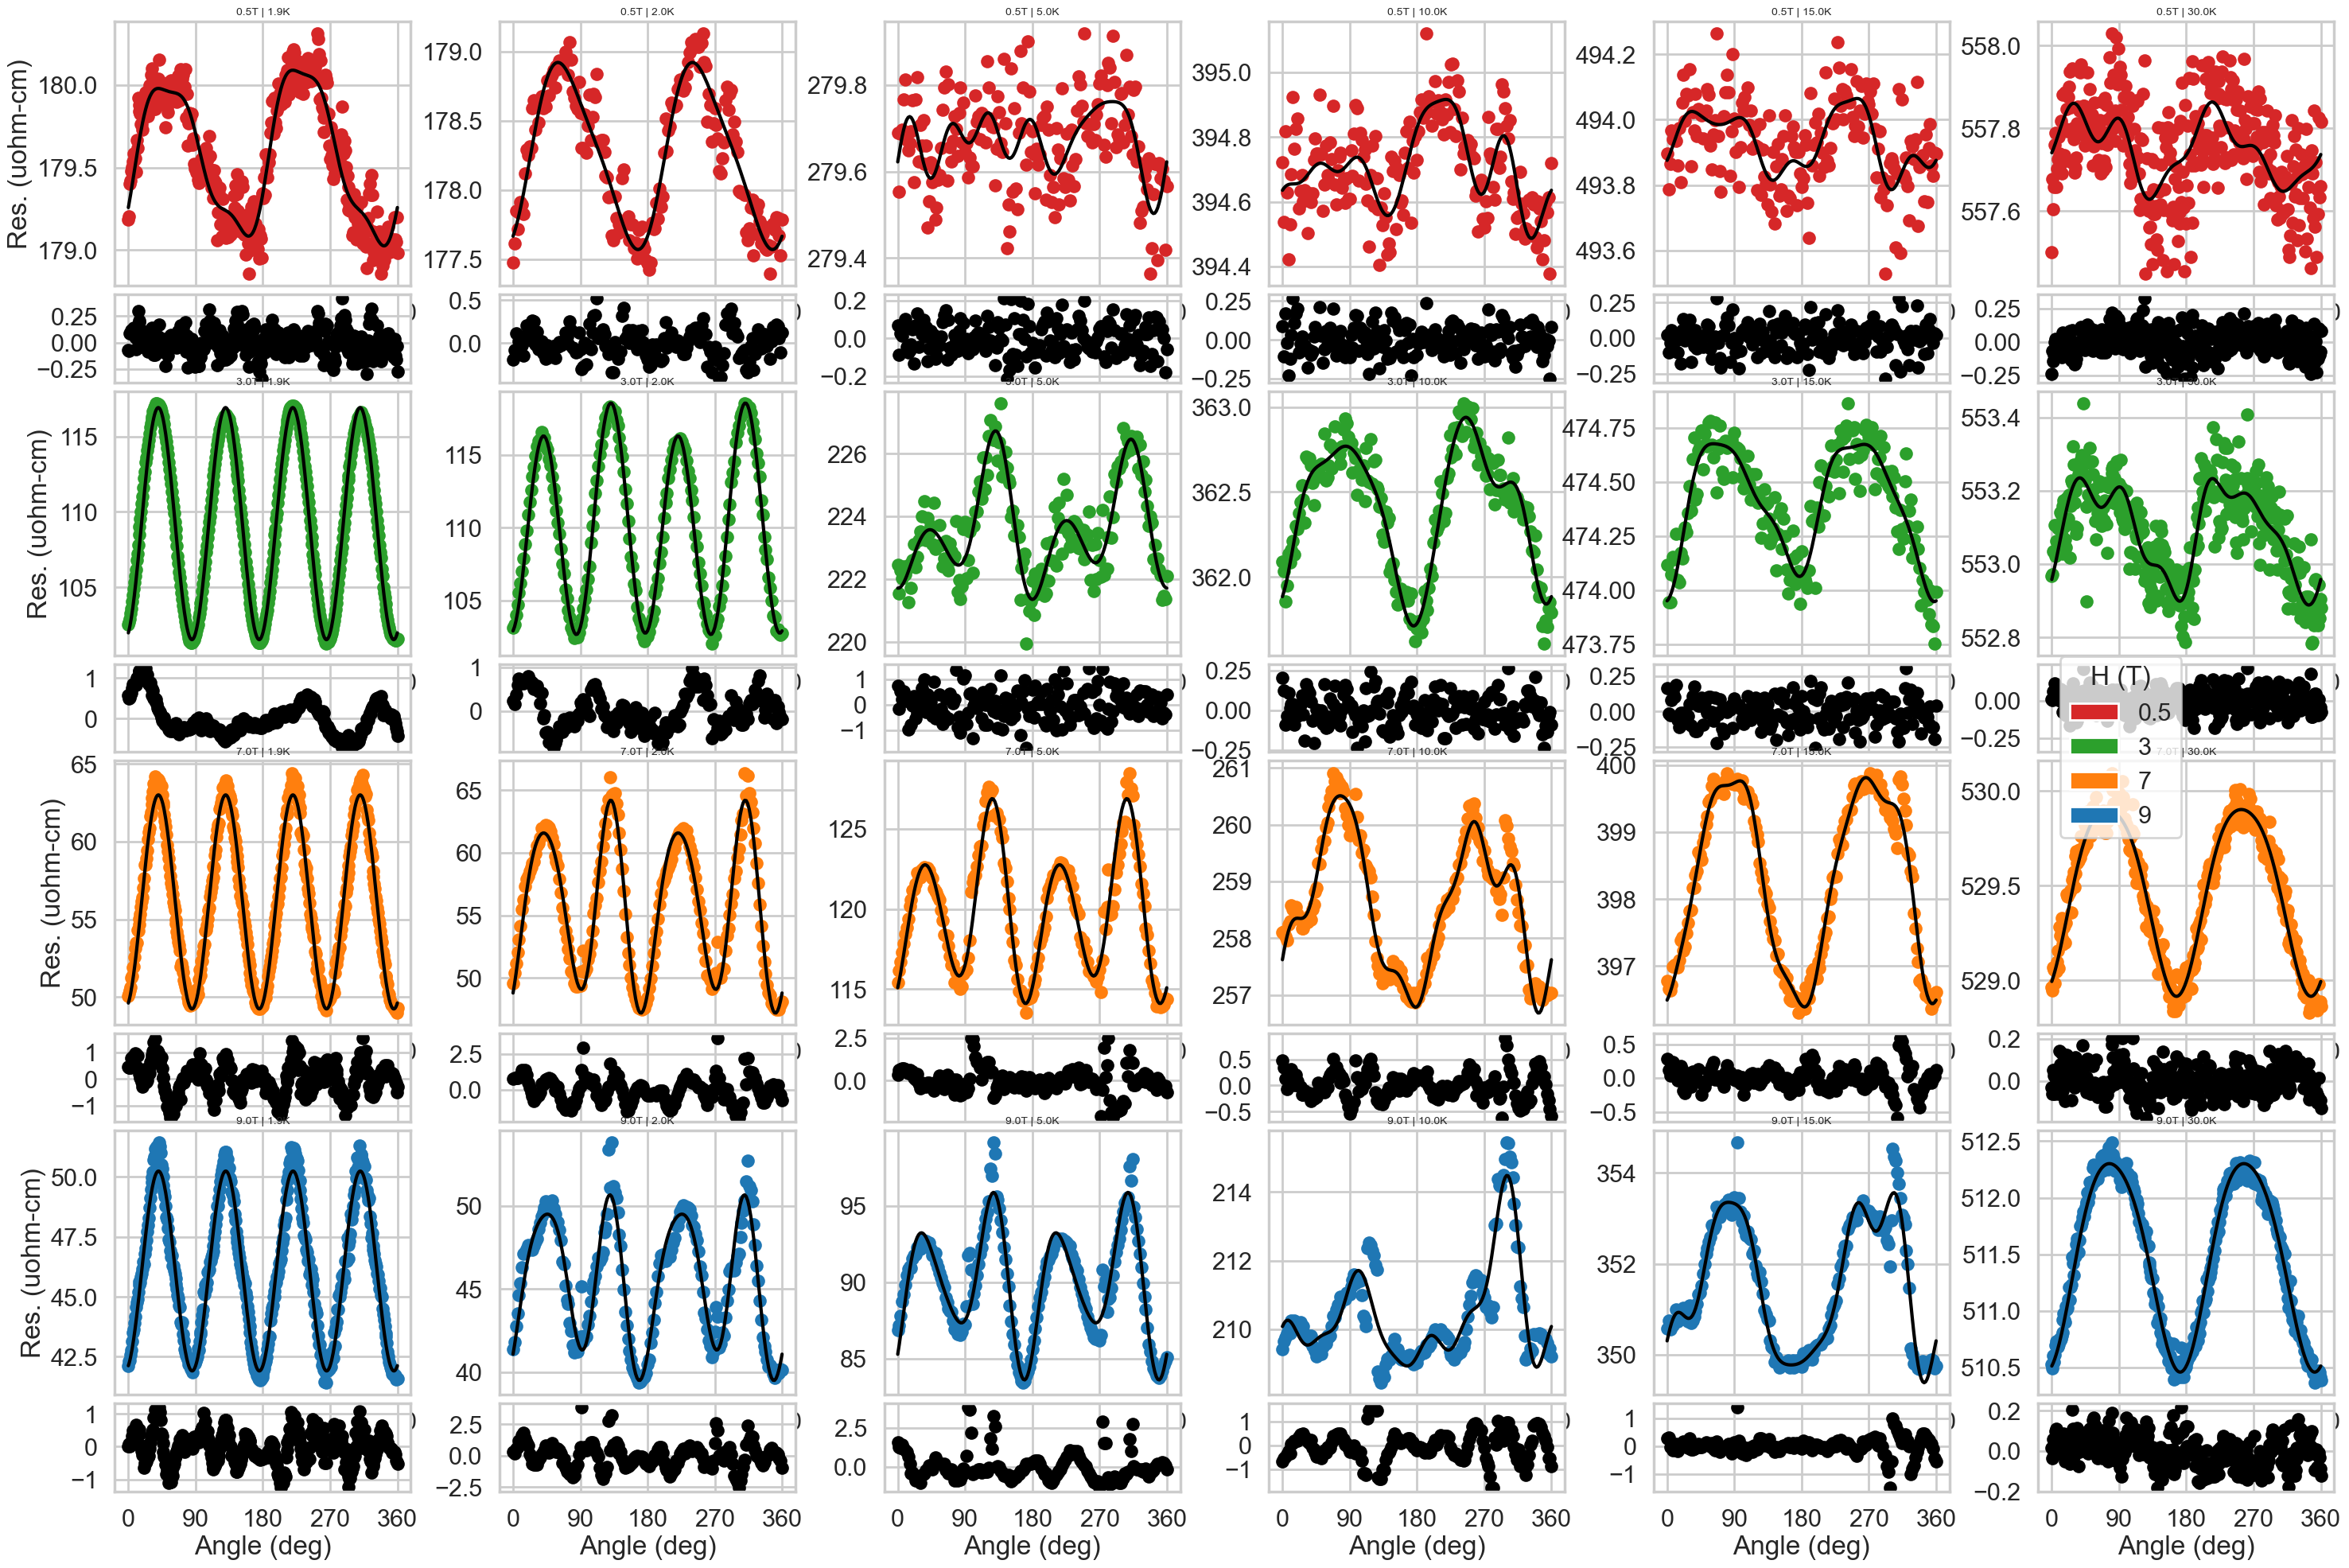

Saved ACTRot12_figure_amro_fits_ratio_0p075_maxf_8_.pdf


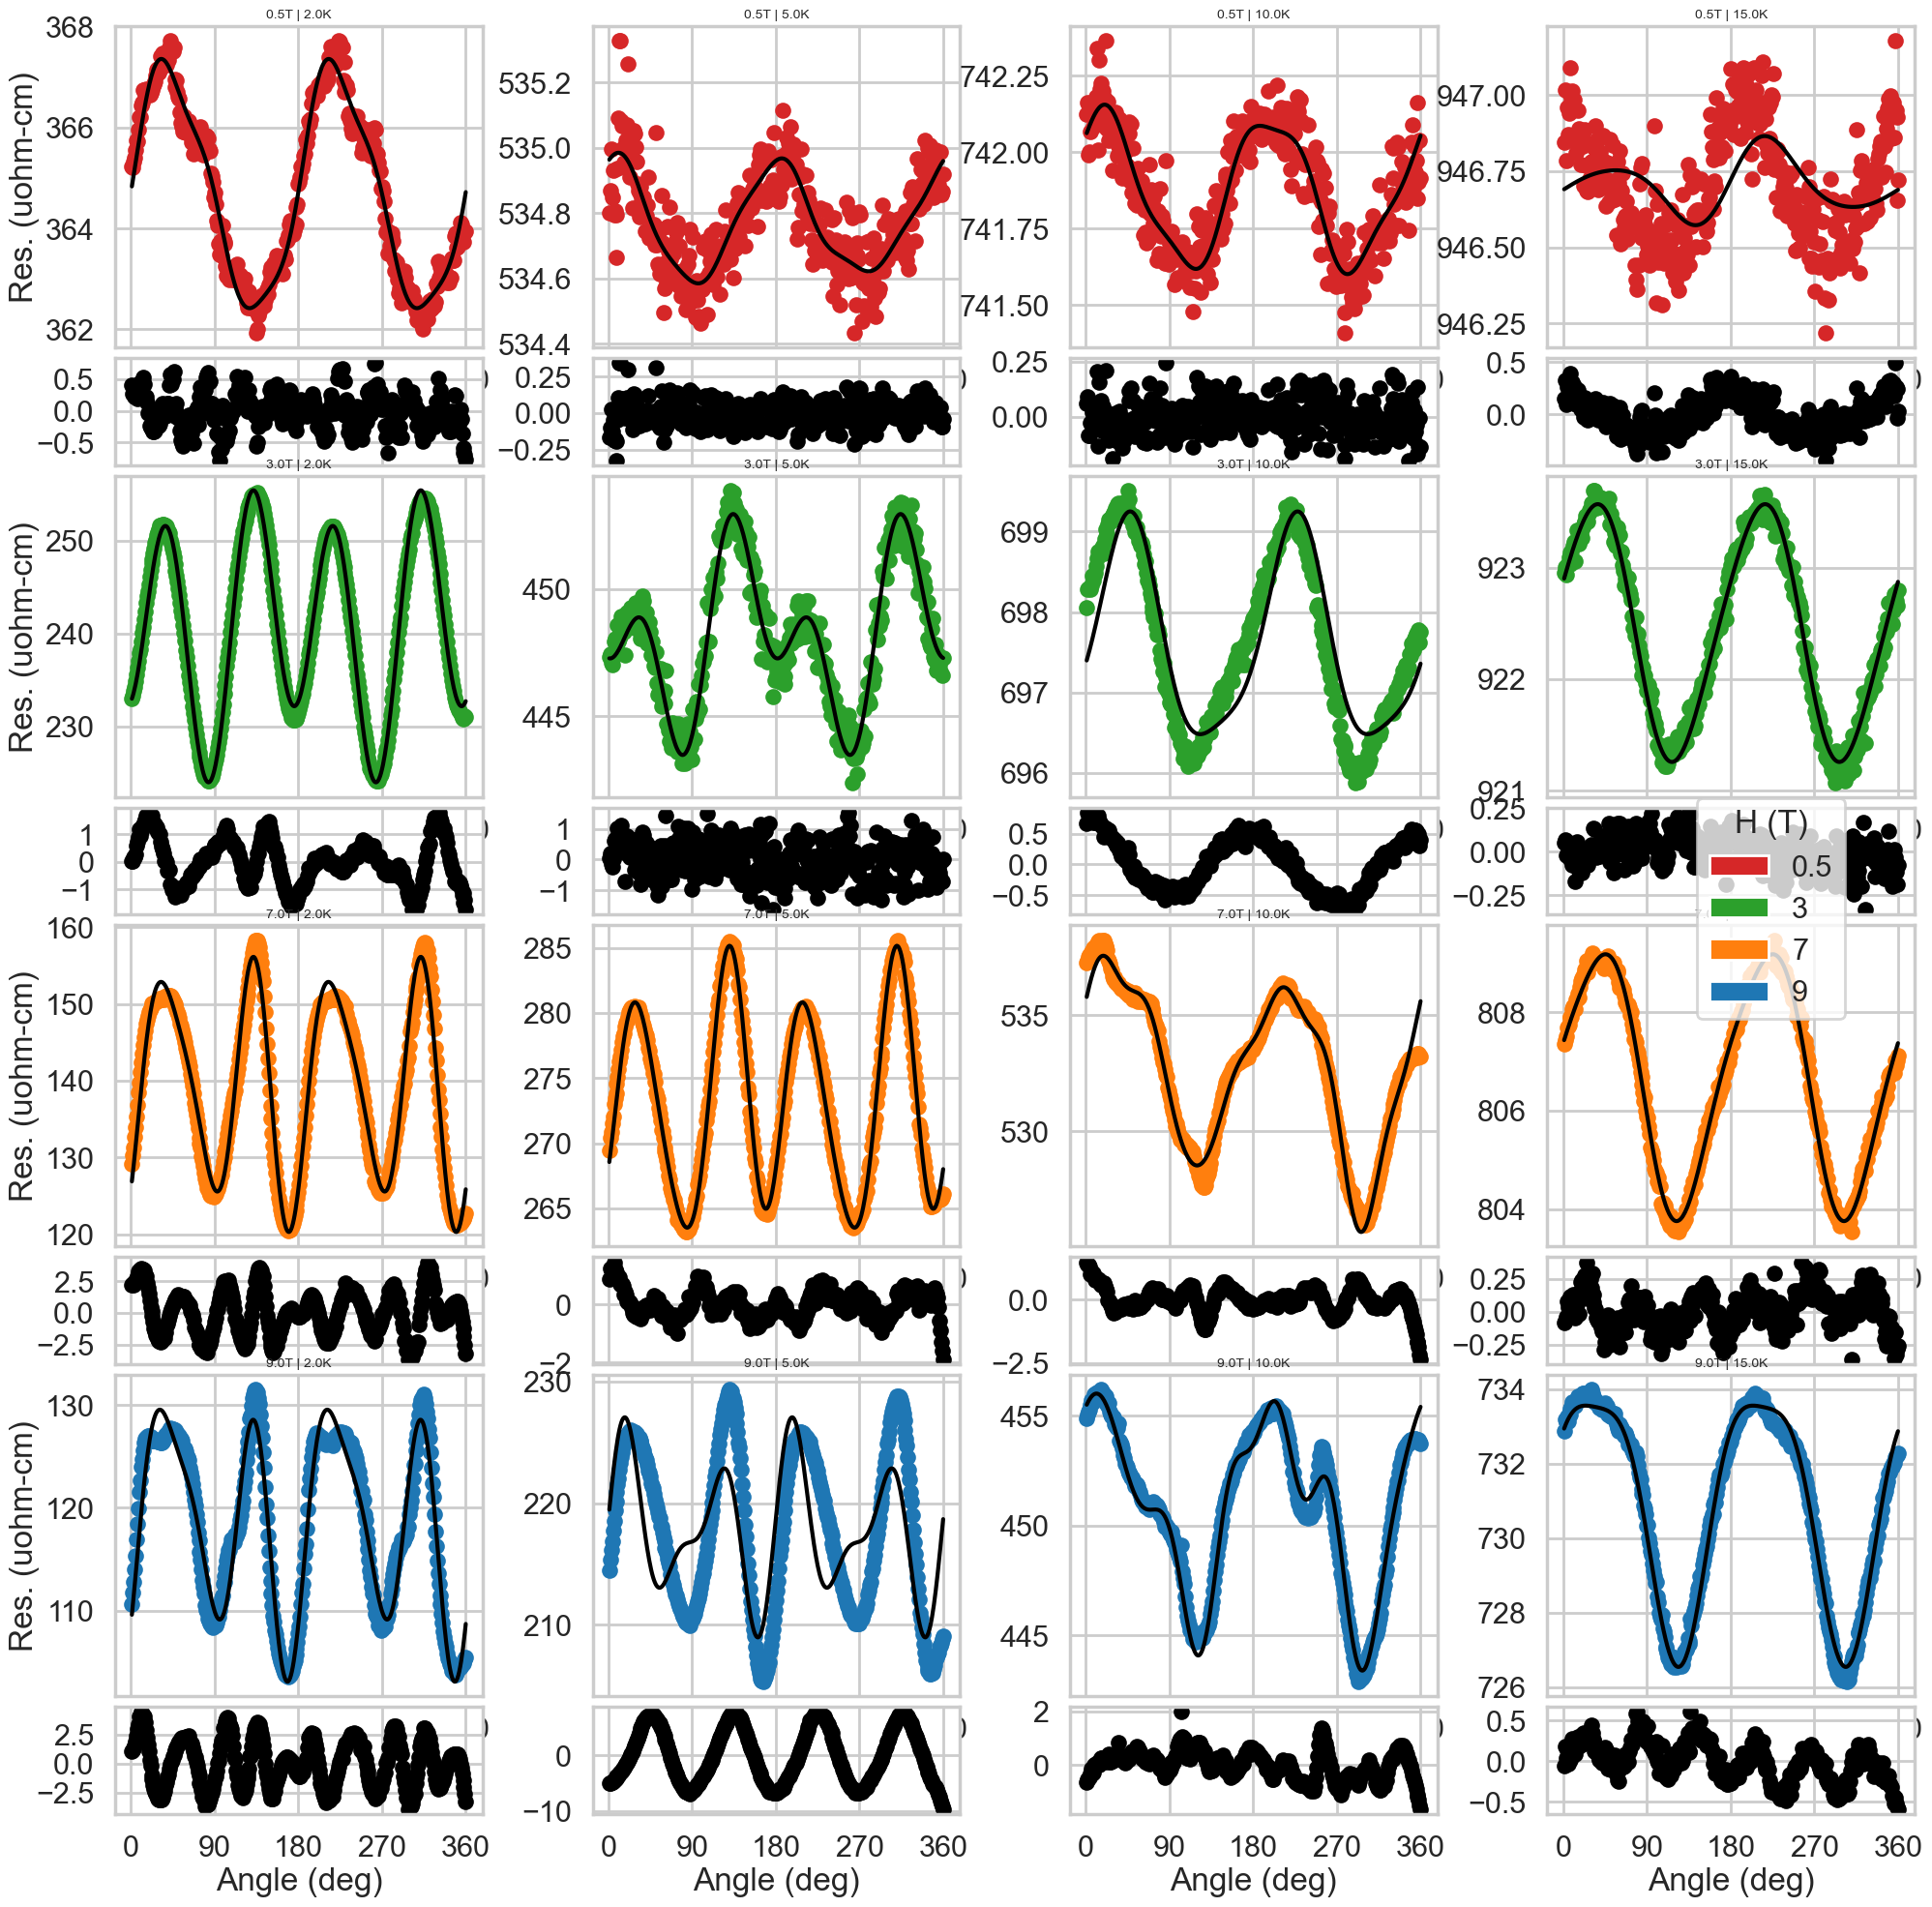

In [9]:
for ACT_label in ['ACTRot11', 'ACTRot12']:
    fig, ax = fitter.plot_fits_with_residuals_uohm(act_choice=ACT_label)
    filename = f"{ACT_label}_figure_{fitter.save_name}.pdf"
    fitter.save_plot(fig,filename)
    plt.show()

## Bad Fits Check

In [10]:
for ACT_label in ['ACTRot11', 'ACTRot12']:
    fig, axes = fitter.plot_bad_fits(act=ACT_label)

No bad fits found for ACTRot11
No bad fits found for ACTRot12


# Save Fit Parameters